# VisDrone -- YOLO11 Training

**Objective**: Train YOLO26 (or latest available YOLO variant) on the merged VisDrone dataset.

**Note**: YOLO26 refers to any future-generation YOLO release. This notebook uses a dynamic model loader that attempts to load the specified model and falls back gracefully if unavailable.

**Environment**: Kaggle Notebook | GPU T4 x1 | Classes: 0=person, 1=car

---
## 1. Setup & Installation

In [1]:
!pip install -q ultralytics

import os, yaml, torch, shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO
from pathlib import Path

print('Ultralytics:', __import__('ultralytics').__version__)
print('CUDA       :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU        :', torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.50
CUDA       : True
GPU        : Tesla T4


---
## 2. Model Selection & Configuration

> Set `TARGET_MODEL` to any Ultralytics-compatible model string.
>
> The `FALLBACK_CHAIN` list defines the order of fallback models if the target is unavailable.

In [2]:
# ── MODEL SELECTION ──────────────────────────────────────────────────────────
MODEL_SIZE     = 's'
TARGET_MODEL   = f'yolo11{MODEL_SIZE}.pt'    # Primary target
FALLBACK_CHAIN = [                           # Tried in order if target fails
    f'yolo12{MODEL_SIZE}.pt',
    f'yolo11{MODEL_SIZE}.pt',
]

MODEL_NAME = None
for candidate in [TARGET_MODEL] + FALLBACK_CHAIN:
    try:
        _test = YOLO(candidate)
        del _test
        MODEL_NAME = candidate
        print(f'Using model: {MODEL_NAME}')
        break
    except Exception as e:
        print(f'  {candidate} not available: {e}')

if MODEL_NAME is None:
    raise RuntimeError('No model in the fallback chain could be loaded. Upgrade Ultralytics.')

# ── TRAINING HYPERPARAMETERS (T4-safe) ───────────────────────────────────────
IMGSZ      = 1280
EPOCHS     = 50
BATCH      = 8
WORKERS    = 4
PATIENCE   = 20
LR0        = 0.01
LRF        = 0.001
DEVICE  = '0,1'


# ── AUGMENTATION (tuned for drone tiny-object detection) ─────────────────────
MOSAIC     = 1.0    # Mandatory
COPY_PASTE = 0.3
MIXUP      = 0.0    # DISABLED -- makes tiny objects smaller
SCALE      = 0.5    # Altitude simulation
FLIPLR     = 0.5
HSV_H      = 0.015
HSV_S      = 0.7
HSV_V      = 0.4


SAVE_NAME = MODEL_NAME.replace('.pt', '') + '_visdrone'
PROJECT   = '/kaggle/working/runs'

print(f'Output name : {SAVE_NAME}')
print(f'imgsz       : {IMGSZ}')
print(f'Batch       : {BATCH}')
print(f'Epochs      : {EPOCHS}')
print(f'Mosaic      : {MOSAIC}  | Copy-paste: {COPY_PASTE}  | Mixup: {MIXUP} (disabled)')
print(f'Scale       : {SCALE}   | FlipLR: {FLIPLR}')


Using model: yolo11s.pt
Output name : yolo11s_visdrone
imgsz       : 1280
Batch       : 8
Epochs      : 50
Mosaic      : 1.0  | Copy-paste: 0.3  | Mixup: 0.0 (disabled)
Scale       : 0.5   | FlipLR: 0.5


---
## 3. Dataset Setup

In [3]:
DATASET_PATH = '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset'

data_yaml = {
    'path' : DATASET_PATH,
    'train': 'VisDrone2019-DET-train/images',
    'val'  : 'VisDrone2019-DET-val/images',
    'test' : 'VisDrone2019-DET-test-dev/images',
    'nc'   : 2,
    'names': {0: 'person', 1: 'car'}
}

DATA_YAML_PATH = '/kaggle/working/data.yaml'
with open(DATA_YAML_PATH, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)
print('data.yaml written.')

data.yaml written.


In [4]:
# ── CELL 3b: Remap Labels + Build Dataset Structure ──────────

import os, yaml
from pathlib import Path
from tqdm.notebook import tqdm

REMAP    = {0: 0, 1: 0, 3: 1}   # pedestrian→person, people→person, car→car
WORK     = Path('/kaggle/working/dataset')

SPLITS = {
    'VisDrone2019-DET-train'    : 'train',
    'VisDrone2019-DET-val'      : 'val',
    'VisDrone2019-DET-test-dev' : 'test',
}

for visdrone_name, short in SPLITS.items():
    src_img_dir = Path(DATASET_PATH) / visdrone_name / 'images'
    src_lbl_dir = Path(DATASET_PATH) / visdrone_name / 'annotations'
    if not src_lbl_dir.exists():
        src_lbl_dir = Path(DATASET_PATH) / visdrone_name / 'labels'

    # ── Symlink images (file-by-file to avoid YOLO path resolution issues) ──
    dst_img = WORK / 'images' / short
    dst_img.mkdir(parents=True, exist_ok=True)
    
    # Only create symlinks if the directory is empty
    if not any(dst_img.iterdir()):
        for img_file in src_img_dir.glob('*.jpg'):
            dest_file = dst_img / img_file.name
            if not dest_file.exists():
                os.symlink(img_file, dest_file)

    # ── Remap + write labels ────────────────────────────────────
    dst_lbl = WORK / 'labels' / short
    dst_lbl.mkdir(parents=True, exist_ok=True)

    kept = discarded = 0
    label_files = sorted(src_lbl_dir.glob('*.txt'))

    for lf in tqdm(label_files, desc=short):
        out_lines = []
        for line in lf.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls = int(parts[0])
            if cls in REMAP:
                out_lines.append(f"{REMAP[cls]} {' '.join(parts[1:])}")
                kept += 1
            else:
                discarded += 1
        (dst_lbl / lf.name).write_text('\n'.join(out_lines))

    print(f'  [{short}]  kept={kept:,}  discarded={discarded:,}  '
          f'({kept/max(kept+discarded,1)*100:.1f}% retained)')

# ── Write data.yaml ─────────────────────────────────────────────
DATA_YAML_PATH = '/kaggle/working/data_remapped.yaml'
with open(DATA_YAML_PATH, 'w') as f:
    yaml.dump({
        'path'  : str(WORK),   # /kaggle/working/dataset
        'train' : 'images/train',
        'val'   : 'images/val',
        'test'  : 'images/test',
        'nc'    : 2,
        'names' : {0: 'person', 1: 'car'},
    }, f, default_flow_style=False)

print(f'\ndata.yaml → {DATA_YAML_PATH}')
print('Done. Ready to train.')


train:   0%|          | 0/6471 [00:00<?, ?it/s]

  [train]  kept=251,263  discarded=91,942  (73.2% retained)


val:   0%|          | 0/548 [00:00<?, ?it/s]

  [val]  kept=28,033  discarded=10,726  (72.3% retained)


test:   0%|          | 0/1610 [00:00<?, ?it/s]

  [test]  kept=55,456  discarded=19,646  (73.8% retained)

data.yaml → /kaggle/working/data_remapped.yaml
Done. Ready to train.


---
## 4. Training

In [5]:
model = YOLO(MODEL_NAME)
print(f'Loaded: {MODEL_NAME}')

Loaded: yolo11s.pt


In [6]:
results = model.train(
    data       = DATA_YAML_PATH,
    epochs     = EPOCHS,
    imgsz      = IMGSZ,
    batch      = BATCH,
    workers    = WORKERS,
    patience   = PATIENCE,
    lr0        = LR0,
    lrf        = LRF,
    device     = DEVICE, 
    mosaic     = MOSAIC,
    copy_paste = COPY_PASTE,
    mixup      = MIXUP,
    scale      = SCALE,
    fliplr     = FLIPLR,
    hsv_h      = HSV_H,
    hsv_s      = HSV_S,
    hsv_v      = HSV_V,
    name       = SAVE_NAME,
    project    = PROJECT,
    save       = True,
    plots      = True,
    verbose    = True,
)
print('Training complete.')

Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_remapped.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_visdro

---
## 5. Validation

In [7]:
best_weights = Path(PROJECT) / SAVE_NAME / 'weights' / 'best.pt'
model_val = YOLO(str(best_weights))
val_results = model_val.val(data=DATA_YAML_PATH, imgsz=IMGSZ, batch=BATCH)

print('=== Validation Results ===')
print(f'mAP50     : {val_results.box.map50:.4f}')
print(f'mAP50-95  : {val_results.box.map:.4f}')
print(f'Precision : {val_results.box.mp:.4f}')
print(f'Recall    : {val_results.box.mr:.4f}')

Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 229.2±54.9 MB/s, size: 131.3 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 51.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 3.8it/s 18.2s
                   all        548      28033      0.817      0.729      0.792       0.49
                person        531      13969      0.779      0.629      0.704      0.337
                   car        515      14064      0.856      0.829       0.88      0.643
Speed: 2.1ms preprocess, 21.2ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
=== Validation Results ===
mAP50     : 0.7916
mAP50-95  : 0.4896
Precision : 0.8174
Re

---
## 6. Visualization

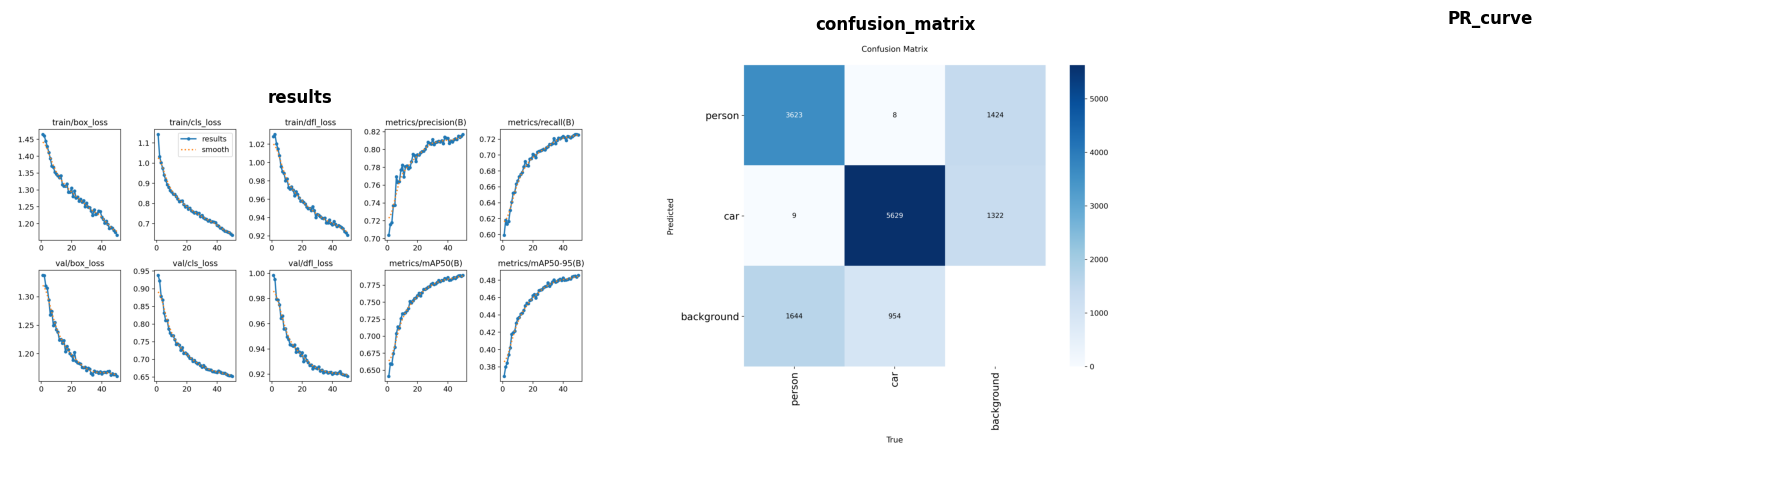

In [8]:
run_dir = Path(PROJECT) / SAVE_NAME
plots_to_show = ['results.png', 'confusion_matrix.png', 'PR_curve.png']
fig, axes = plt.subplots(1, len(plots_to_show), figsize=(18, 5))
for ax, p in zip(axes, plots_to_show):
    fp = run_dir / p
    ax.imshow(mpimg.imread(str(fp))) if fp.exists() else None
    ax.set_title(p.replace('.png', ''), fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()


0: 736x1280 28 persons, 13 cars, 28.9ms
1: 736x1280 37 persons, 16 cars, 28.9ms
2: 736x1280 39 persons, 4 cars, 28.9ms
Speed: 7.5ms preprocess, 28.9ms inference, 1.3ms postprocess per image at shape (1, 3, 736, 1280)
Results saved to /kaggle/working/runs/yolo11s_visdrone_inference


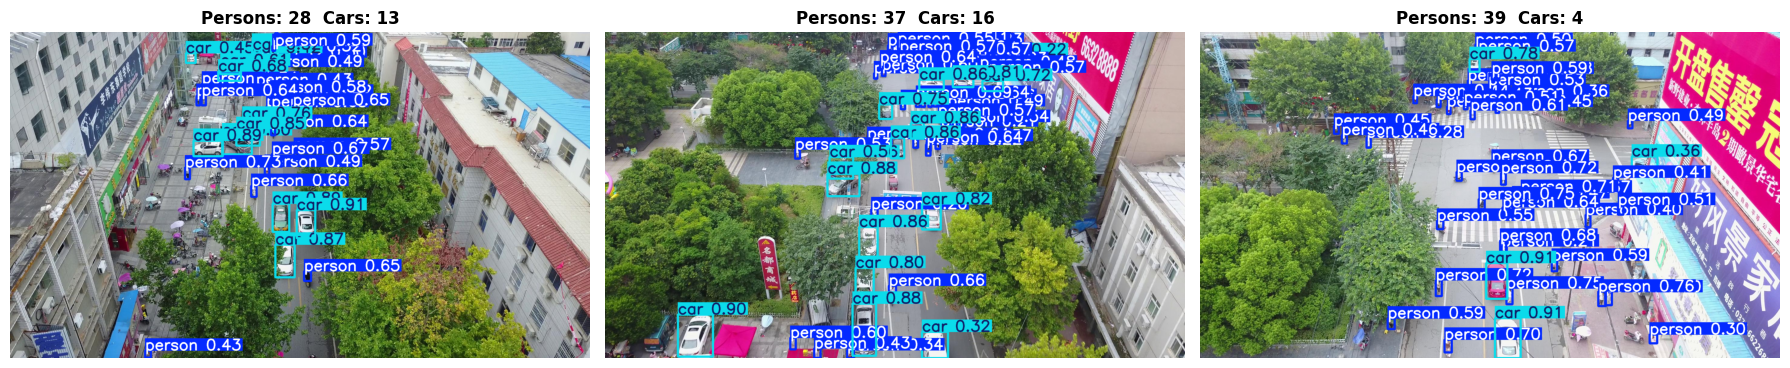

In [9]:
val_img_dir = os.path.join(DATASET_PATH, 'VisDrone2019-DET-val', 'images')
val_imgs = sorted(os.listdir(val_img_dir))[:3]
preds = model_val.predict(
    source=[os.path.join(val_img_dir, f) for f in val_imgs],
    imgsz=IMGSZ, conf=0.20, iou=0.45,
    save=True, project=PROJECT, name=SAVE_NAME + '_inference',
)
fig, axes = plt.subplots(1, len(preds), figsize=(18, 6))
for ax, r in zip(axes, preds):
    ax.imshow(r.plot()[:, :, ::-1])
    ax.set_title(f'Persons: {(r.boxes.cls==0).sum().item()}  Cars: {(r.boxes.cls==1).sum().item()}',
                 fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## 7. Results & Export

In [10]:
print('=' * 50)
print(f' Model    : {SAVE_NAME}')
print(f' mAP50    : {val_results.box.map50:.4f}')
print(f' mAP50-95 : {val_results.box.map:.4f}')
print(f' Precision: {val_results.box.mp:.4f}')
print(f' Recall   : {val_results.box.mr:.4f}')
print('=' * 50)

dest = f'/kaggle/working/{SAVE_NAME}.pt'
shutil.copy(str(best_weights), dest)
print(f'Weights saved to: {dest}')

 Model    : yolo11s_visdrone
 mAP50    : 0.7916
 mAP50-95 : 0.4896
 Precision: 0.8174
 Recall   : 0.7290
Weights saved to: /kaggle/working/yolo11s_visdrone.pt
